In [1]:
!pip install -q transformers
!pip install -q datasets
!pip install -q sentencepiece
!pip install -q sacrebleu
!pip install -q evaluate
!pip install -q accelerate
!pip install -q bert-score
!pip install -q nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import torch

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)

In [3]:
train_sa = pd.read_csv("train_sa_10000.csv")
train_en = pd.read_csv("train_en_10000.csv")

dev_sa = pd.read_csv("dev_sa_1000.csv")
dev_en = pd.read_csv("dev_en_1000.csv")

test_sa = pd.read_csv("test_sa_1000.csv")
test_en = pd.read_csv("test_en_1000.csv")

In [5]:
train_df = train_sa.merge(train_en,on="Source_id")
dev_df = dev_sa.merge(dev_en,on="Source_id")
test_df = test_sa.merge(test_en,on="Source_id")

In [6]:
train_df = train_df.rename(
    columns={
        "Sentence_sa":"source",
        "Sentence_en":"target"
    }
)

dev_df = dev_df.rename(
    columns={
        "Sentence_sa":"source",
        "Sentence_en":"target"
    }
)

test_df = test_df.rename(
    columns={
        "Sentence_sa":"source",
        "Sentence_en":"target"
    }
)

In [7]:
train_dataset = Dataset.from_pandas(
    train_df[["source","target"]]
)

dev_dataset = Dataset.from_pandas(
    dev_df[["source","target"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["source","target"]]
)

In [8]:
train_dataset

Dataset({
    features: ['source', 'target'],
    num_rows: 10000
})

In [9]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "facebook/nllb-200-distilled-600M"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = model.to(device)

print("Loaded Successfully")

config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/3.55k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Loaded Successfully


In [11]:
tokenizer

NllbTokenizer(name_or_path='facebook/nllb-200-distilled-600M', vocab_size=256204, model_max_length=1024, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	256001: AddedToken("ace_Arab", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	256002: AddedToken("ace_Latn", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	256003: AddedToken("

In [14]:
for lang_token in tokenizer.added_tokens_decoder.values():
    if "san" in lang_token.content.lower():
        print(lang_token.content)

san_Deva


In [16]:
SRC_LANG = "san_Deva"
TGT_LANG = "eng_Latn"

tokenizer.src_lang = SRC_LANG

In [17]:
sample = train_df.iloc[0]["source"]

tokens = tokenizer(sample)

print(sample)

print(tokens["input_ids"][:20])

"Ctrl, S नुत्वा रक्षन्तु।"
[256149, 69, 248181, 480, 248069, 248079, 83, 109516, 33951, 195496, 31598, 33928, 2]


In [18]:
decoded = tokenizer.decode(
    tokens["input_ids"],
    skip_special_tokens=True
)

print(decoded)

"Ctrl, S नुत्वा रक्षन्तु।"


In [21]:
sample = train_df.iloc[0]["source"]

inputs = tokenizer(
    sample,
    return_tensors="pt"
).to(device)

# Find the token ID for the target language
target_lang_token_id = None
for token_id, added_token in tokenizer.added_tokens_decoder.items():
    if added_token.content == TGT_LANG:
        target_lang_token_id = token_id
        break

if target_lang_token_id is None:
    raise ValueError(f"Language token ID for '{TGT_LANG}' not found in tokenizer.added_tokens_decoder.")

generated_ids = model.generate(
    **inputs,
    forced_bos_token_id=target_lang_token_id,
    max_length=64
)

prediction = tokenizer.batch_decode(
    generated_ids,
    skip_special_tokens=True
)

print("Input:")
print(sample)

print("\nPrediction:")
print(prediction[0])

print("\nReference:")
print(train_df.iloc[0]["target"])

Input:
"Ctrl, S नुत्वा रक्षन्तु।"

Prediction:
"Ctrl, S and save".

Reference:
Save it with Ctrl, S.


In [22]:
!pip install -q peft bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.1 MB/s eta 0:00:00


In [23]:
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

from transformers import DataCollatorForSeq2Seq

In [24]:
lora_config = LoraConfig(

    task_type=TaskType.SEQ_2_SEQ_LM,

    inference_mode=False,

    r=16,

    lora_alpha=32,

    lora_dropout=0.1,

    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj"
    ]
)

In [26]:
!pip install --upgrade torchao

model = get_peft_model(
    model,
    lora_config
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 74.6 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [27]:
model.print_trainable_parameters()

trainable params: 3,538,944 || all params: 618,612,736 || trainable%: 0.5721


In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)

PeftModelForSeq2SeqLM(
  (base_model): LoraModel(
    (model): M2M100ForConditionalGeneration(
      (model): M2M100Model(
        (shared): M2M100ScaledWordEmbedding(256206, 1024, padding_idx=1)
        (encoder): M2M100Encoder(
          (embed_tokens): M2M100ScaledWordEmbedding(256206, 1024, padding_idx=1)
          (embed_positions): M2M100SinusoidalPositionalEmbedding()
          (layers): ModuleList(
            (0-11): 12 x M2M100EncoderLayer(
              (self_attn): M2M100Attention(
                (k_proj): lora.Linear(
                  (base_layer): Linear(in_features=1024, out_features=1024, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=1024, out_features=16, bias=False)
                  )
                  (lora_B): ModuleDict(
                    (default): Linear(in_features=16, out_featu

In [29]:
MAX_SOURCE_LENGTH = 128
MAX_TARGET_LENGTH = 128


def preprocess(example):

    model_inputs = tokenizer(
        example["source"],
        max_length=MAX_SOURCE_LENGTH,
        truncation=True
    )

    labels = tokenizer(
        text_target=example["target"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs


train_dataset = train_dataset.map(
    preprocess,
    batched=True,
    remove_columns=train_dataset.column_names
)

dev_dataset = dev_dataset.map(
    preprocess,
    batched=True,
    remove_columns=dev_dataset.column_names
)

test_dataset = test_dataset.map(
    preprocess,
    batched=True,
    remove_columns=test_dataset.column_names
)

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [30]:
print(train_dataset[0])

{'input_ids': [256149, 69, 248181, 480, 248069, 248079, 83, 109516, 33951, 195496, 31598, 33928, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': [256149, 102960, 796, 2790, 152, 480, 248069, 248079, 83, 248075, 2]}


In [31]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

In [32]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

In [33]:
!pip install -q evaluate

In [34]:
import evaluate
import numpy as np

from transformers import (
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    EarlyStoppingCallback
)

In [35]:
bleu = evaluate.load("sacrebleu")

In [36]:
def compute_metrics(eval_preds):

    predictions, labels = eval_preds

    if isinstance(predictions, tuple):
        predictions = predictions[0]

    decoded_preds = tokenizer.batch_decode(
        predictions,
        skip_special_tokens=True
    )

    labels = np.where(
        labels != -100,
        labels,
        tokenizer.pad_token_id
    )

    decoded_labels = tokenizer.batch_decode(
        labels,
        skip_special_tokens=True
    )

    decoded_labels = [[label] for label in decoded_labels]

    bleu_score = bleu.compute(
        predictions=decoded_preds,
        references=decoded_labels
    )

    return {
        "bleu": bleu_score["score"]
    }

In [45]:
training_args = Seq2SeqTrainingArguments(

    output_dir="./nllb_sanskrit",

    # overwrite_output_dir=True, # Removed due to TypeError

    num_train_epochs=10,

    learning_rate=2e-4,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    gradient_accumulation_steps=2,

    predict_with_generate=True,

    generation_max_length=128,

    fp16=torch.cuda.is_available(),

    # evaluation_strategy="epoch",

    save_strategy="epoch",

    logging_strategy="steps",

    logging_steps=50,

    save_total_limit=2,

    load_best_model_at_end=False, # Changed to False to resolve ValueError

    metric_for_best_model="bleu",

    greater_is_better=True,

    report_to="none",

    warmup_ratio=0.1,

    weight_decay=0.01,

    lr_scheduler_type="cosine",

    remove_unused_columns=True
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [49]:
trainer = Seq2SeqTrainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=dev_dataset,

    tokenizer=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=3
        )
    ]
)

In [50]:
trainer.train()

Step,Training Loss
50,8.061134
100,7.653465
150,6.541866
200,5.191575
250,4.229736
300,3.974847
350,3.733492
400,3.905247
450,3.850801
500,3.879390


TrainOutput(global_step=6250, training_loss=3.2866084375, metrics={'train_runtime': 2319.9887, 'train_samples_per_second': 43.104, 'train_steps_per_second': 2.694, 'total_flos': 1.0757383583367168e+16, 'train_loss': 3.2866084375, 'epoch': 10.0})

In [51]:
trainer.save_model("best_nllb_model")

tokenizer.save_pretrained("best_nllb_model")

('best_nllb_model/tokenizer_config.json', 'best_nllb_model/tokenizer.json')

In [52]:
results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Step,Bleu
2.934651,1.489236,6250,28.320105


{'eval_loss': 1.4892363548278809, 'eval_bleu': 28.320104867126524}


In [55]:
def translate(sentence):

    tokenizer.src_lang = SRC_LANG

    inputs = tokenizer(
        sentence,
        return_tensors="pt"
    ).to(device)

    # Find the token ID for the target language (similar to previous successful approach)
    target_lang_token_id = None
    for token_id, added_token in tokenizer.added_tokens_decoder.items():
        if added_token.content == TGT_LANG:
            target_lang_token_id = token_id
            break

    if target_lang_token_id is None:
        raise ValueError(f"Language token ID for '{TGT_LANG}' not found in tokenizer.added_tokens_decoder.")

    generated_tokens = model.generate(
        **inputs,
        forced_bos_token_id=target_lang_token_id,
        max_length=128,
        num_beams=5,
        early_stopping=True
    )

    prediction = tokenizer.batch_decode(
        generated_tokens,
        skip_special_tokens=True
    )[0]

    return prediction

In [67]:
sample = dev_df.iloc[0]

print("SOURCE")
print(sample["source"])

print("\nREFERENCE")
print(sample["target"])

prediction = translate(
    sample["source"]
)

print("\nPREDICTION")
print(prediction)

SOURCE
ते वीराः ।

REFERENCE
Those are brave men.

PREDICTION
Those are heroes.


In [57]:
from tqdm.auto import tqdm

predictions = []

for sentence in tqdm(test_df["source"]):

    pred = translate(sentence)

    predictions.append(pred)

test_df["prediction"] = predictions

  0%|          | 0/1000 [00:00<?, ?it/s]

In [59]:
submission = pd.DataFrame({

    "Source id": test_sa["Source_id"],

    "Sentence en": predictions

})

submission.to_csv(

    "submission.csv",

    index=False,

    encoding="utf-8"

)

print(submission.head())

   Source id                                        Sentence en
0          1  Eclipse also helps in troubleshooting for prog...
1          2  "By faith I say, Speak. And we have the confid...
2          3  Then it will automatically search for the driv...
3          4  For all iterations, the iterator is set to the...
4          5  "And when he had opened the second seal, behol...


In [60]:
trainer.save_model("best_nllb_model")

In [61]:
import shutil

shutil.make_archive(

    "best_nllb_model",

    "zip",

    "best_nllb_model"

)

'/content/best_nllb_model.zip'

In [62]:
from google.colab import files

files.download(
    "best_nllb_model.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [63]:
files.download(
    "submission.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
!pip install -q bert-score nltk

In [77]:
import time
import nltk
import pandas as pd

from nltk.translate.bleu_score import corpus_bleu
from bert_score import score

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [68]:
from tqdm.auto import tqdm

predictions = []

start_time = time.time()

for sentence in tqdm(dev_df["source"]):

    tokenizer.src_lang = SRC_LANG

    inputs = tokenizer(
        sentence,
        return_tensors="pt"
    ).to(device)

    # Find the token ID for the target language (similar to previous successful approach)
    target_lang_token_id = None
    for token_id, added_token in tokenizer.added_tokens_decoder.items():
        if added_token.content == TGT_LANG:
            target_lang_token_id = token_id
            break

    if target_lang_token_id is None:
        raise ValueError(f"Language token ID for '{TGT_LANG}' not found in tokenizer.added_tokens_decoder.")

    generated_tokens = model.generate(
        **inputs,
        forced_bos_token_id=target_lang_token_id,
        num_beams=5,
        max_new_tokens=128,
        early_stopping=True
    )

    pred = tokenizer.batch_decode(
        generated_tokens,
        skip_special_tokens=True
    )[0]

    predictions.append(pred)

end_time = time.time()

total_inference_time = end_time - start_time

print(f"Total Inference Time : {total_inference_time:.2f} seconds")

  0%|          | 0/1000 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

Total Inference Time : 656.47 seconds


In [71]:
references = [
    [nltk.word_tokenize(ref.lower())]
    for ref in dev_df["target"]
]

hypotheses = [
    nltk.word_tokenize(pred.lower())
    for pred in predictions
]

bleu_score = corpus_bleu(
    references,
    hypotheses
)

print("="*50)
print(f"NLTK BLEU : {bleu_score:.4f}")
print("="*50)

NLTK BLEU : 0.3021


In [72]:
P, R, F1 = score(
    predictions,
    dev_df["target"].tolist(),
    lang="en",
    rescale_with_baseline=True
)

bert_f1 = F1.mean().item()

print("="*50)
print(f"BERTScore F1 : {bert_f1:.4f}")
print("="*50)

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore F1 : 0.6192


In [73]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("="*50)
print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")
print("="*50)

Total Parameters      : 618,612,736
Trainable Parameters  : 3,538,944


In [74]:
results = pd.DataFrame({

    "Metric":[
        "NLTK BLEU",
        "BERTScore F1",
        "Inference Time (seconds)",
        "Total Parameters",
        "Trainable Parameters"
    ],

    "Value":[
        bleu_score,
        bert_f1,
        total_inference_time,
        total_params,
        trainable_params
    ]
})

results

,Metric,Value
0,NLTK BLEU,3.020649e-01
1,BERTScore F1,6.191629e-01
2,Inference Time (seconds),6.564746e+02
3,Total Parameters,6.186127e+08
4,Trainable Parameters,3.538944e+06


In [79]:
from tqdm.auto import tqdm
import pandas as pd

NUM_EXAMPLES = 10

examples = []

for i in range(NUM_EXAMPLES):

    source = dev_df.iloc[i]["source"]
    reference = dev_df.iloc[i]["target"]

    tokenizer.src_lang = SRC_LANG

    inputs = tokenizer(
        source,
        return_tensors="pt"
    ).to(device)

    # Find the token ID for the target language (reusing the successful approach)
    target_lang_token_id = None
    for token_id, added_token in tokenizer.added_tokens_decoder.items():
        if added_token.content == TGT_LANG:
            target_lang_token_id = token_id
            break

    if target_lang_token_id is None:
        raise ValueError(f"Language token ID for '{TGT_LANG}' not found in tokenizer.added_tokens_decoder.")

    generated_tokens = model.generate(
        **inputs,
        forced_bos_token_id=target_lang_token_id,
        num_beams=5,
        max_new_tokens=128,
        early_stopping=True
    )

    prediction = tokenizer.batch_decode(
        generated_tokens,
        skip_special_tokens=True
    )[0]

    examples.append({
        "Sanskrit": source,
        "Reference": reference,
        "Prediction": prediction
    })

examples_df = pd.DataFrame(examples)

examples_df.to_csv(
    "translation_examples.csv",
    index=False,
    encoding="utf-8"
)

for idx, row in examples_df.iterrows():

    print("=" * 120)
    print(f"Example {idx+1}")
    print()
    print("Sanskrit :")
    print(row["Sanskrit"])
    print()
    print("Reference :")
    print(row["Reference"])
    print()
    print("Prediction :")
    print(row["Prediction"])
    print()

print("\nSaved as translation_examples.csv")

[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

Example 1

Sanskrit :
ते वीराः ।

Reference :
Those are brave men.

Prediction :
Those are heroes.

Example 2

Sanskrit :
'इन्फ़ैनेट् लूप्' इतीदं व्यवस्थां निरुत्तरां कारयति ।

Reference :
Infinite loop  can cause the system to become unresponsive.

Prediction :
The infinite loop disrupts the system.

Example 3

Sanskrit :
ततस्तस्य गात्रे निष्ठीवं दत्वा तेन वेत्रेण शिर आजघ्नुः।

Reference :
"And they spit upon him, and took the reed, and smote him on the head."

Prediction :
"And they thrust him into the throat with a staff, and struck his head with a sword."

Example 4

Sanskrit :
एते तिथी ।

Reference :
These two are dates.

Prediction :
These two are Titans.

Example 5

Sanskrit :
"बहुविचारेषु जातषु पितर उत्थाय कथितवान्, हे भ्रातरो यथा भिन्नदेशीयलोका मम मुखात् सुसंवादं श्रुत्वा विश्वसन्ति तदर्थं बहुदिनात् पूर्व्वम् ईश्वरोस्माकं मध्ये मां वृत्वा नियुक्तवान्।"

Reference :
"And when there had been much disputing, Peter rose up, and said unto them, Men and brethren, ye know how that a 

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert trainer logs to DataFrame
history = pd.DataFrame(trainer.state.log_history)

# Display available columns
print(history.columns)

Index(['loss', 'grad_norm', 'learning_rate', 'epoch', 'step', 'train_runtime',
       'train_samples_per_second', 'train_steps_per_second', 'total_flos',
       'train_loss', 'eval_loss', 'eval_bleu', 'eval_runtime',
       'eval_samples_per_second', 'eval_steps_per_second'],
      dtype='object')


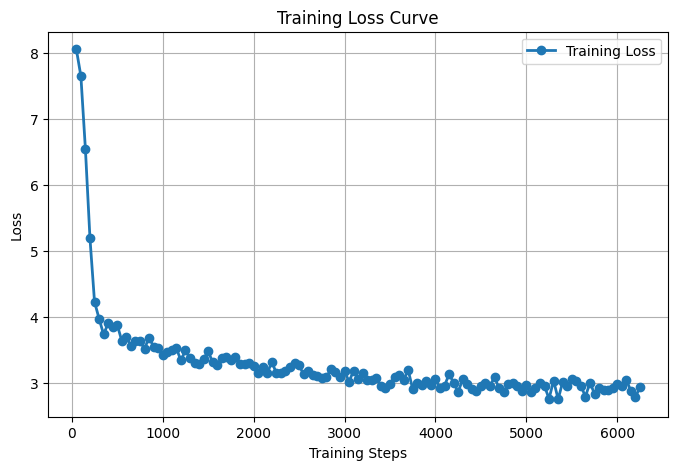

In [81]:
import matplotlib.pyplot as plt

train_logs = history.dropna(subset=["loss"])

plt.figure(figsize=(8,5))

plt.plot(
    train_logs["step"],
    train_logs["loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.legend()

plt.savefig(
    "training_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

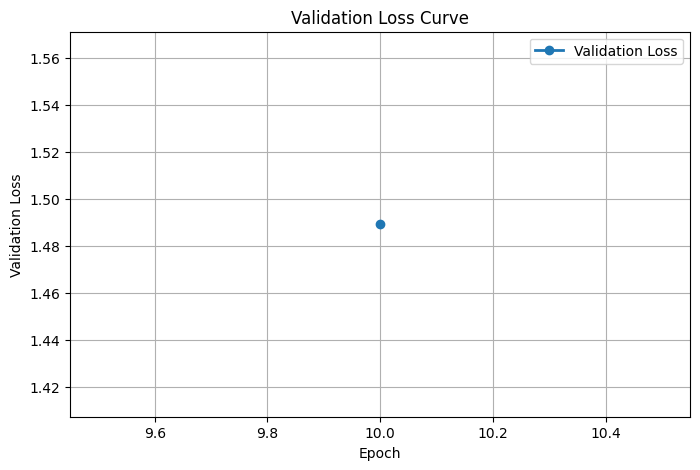

In [82]:
eval_logs = history.dropna(subset=["eval_loss"])

plt.figure(figsize=(8,5))

plt.plot(
    eval_logs["epoch"],
    eval_logs["eval_loss"],
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Curve")
plt.grid(True)
plt.legend()

plt.savefig(
    "validation_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

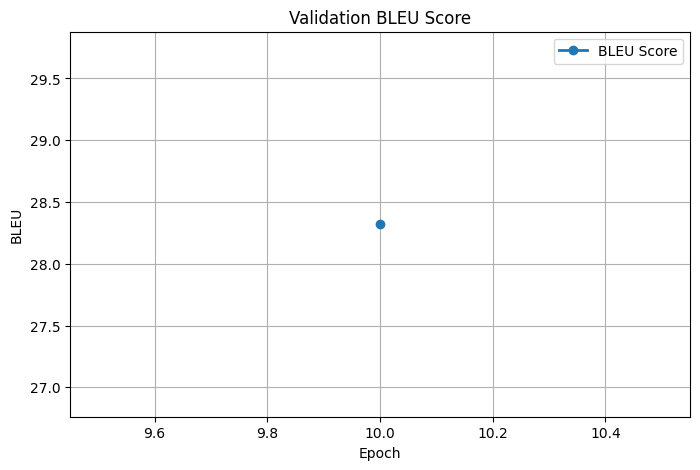

In [83]:
eval_logs = history.dropna(subset=["eval_bleu"])

plt.figure(figsize=(8,5))

plt.plot(
    eval_logs["epoch"],
    eval_logs["eval_bleu"],
    marker="o",
    linewidth=2,
    label="BLEU Score"
)

plt.xlabel("Epoch")
plt.ylabel("BLEU")
plt.title("Validation BLEU Score")
plt.grid(True)
plt.legend()

plt.savefig(
    "bleu_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

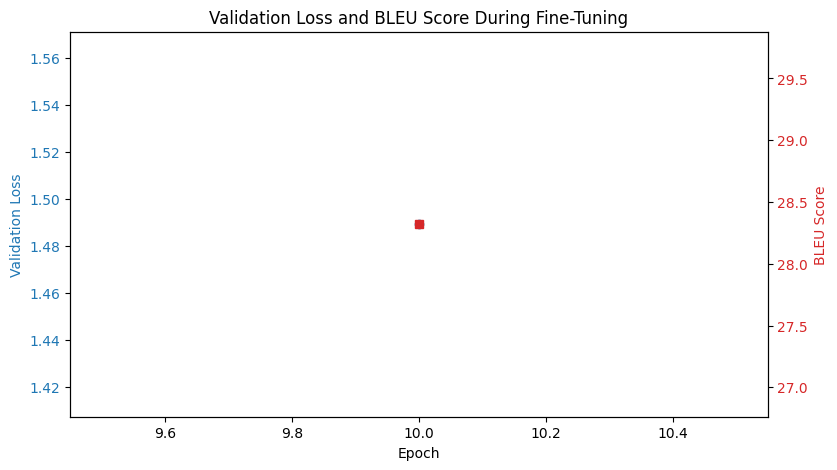

In [84]:
fig, ax1 = plt.subplots(figsize=(9,5))

# Validation Loss
ax1.plot(
    eval_logs["epoch"],
    eval_logs["eval_loss"],
    color="tab:blue",
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Validation Loss", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# BLEU on second axis
ax2 = ax1.twinx()

ax2.plot(
    eval_logs["epoch"],
    eval_logs["eval_bleu"],
    color="tab:red",
    marker="s",
    linewidth=2,
    label="BLEU"
)

ax2.set_ylabel("BLEU Score", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Validation Loss and BLEU Score During Fine-Tuning")

plt.savefig(
    "training_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()